### Materi

Instalasi Library

In [22]:
!pip install networkx matplotlib

Struktur Data Graf dan Algoritma

In [23]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths (graph, start):
  distances = {node: float('inf') for node in graph}
  distances [start] = 0
  previous = {node: None for node in graph}
  queue = [(0, start)]
  while queue:
    current_distance, current_node = heapq.heappop (queue)

    for neighbor, weight in graph [current_node].items() :
      distance = current_distance + weight
      if distance < distances [neighbor]:
        distances [neighbor] = distance
        previous [neighbor] = current_node
        heapq.heappush (queue, (distance, neighbor))

  return distances, previous


Fungsi untuk Merekonstruksi Jalur

In [24]:
def get_path (previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous [target]
  return path

Visualisasi dengan networkx dan matplotlib

In [25]:
def visualize_graph (graph, path=None):
  G = nx.DiGraph()
  for node in graph:
    for neighbor, weight in graph [node].items():
      G.add_edge (node, neighbor, weight=weight)
  pos = nx.spring_layout (G)
  edge_labels = nx.get_edge_attributes (G, 'weight')

  plt.figure (figsize=(8, 6))
  nx.draw (G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len (path) > 1:
    path_edges = list (zip (path, path[1:]))
    nx.draw_networkx_edges (G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show ()


Penggunaan Lengkap

Jarak dari A ke Z: 14
Jalur: ABDEZ


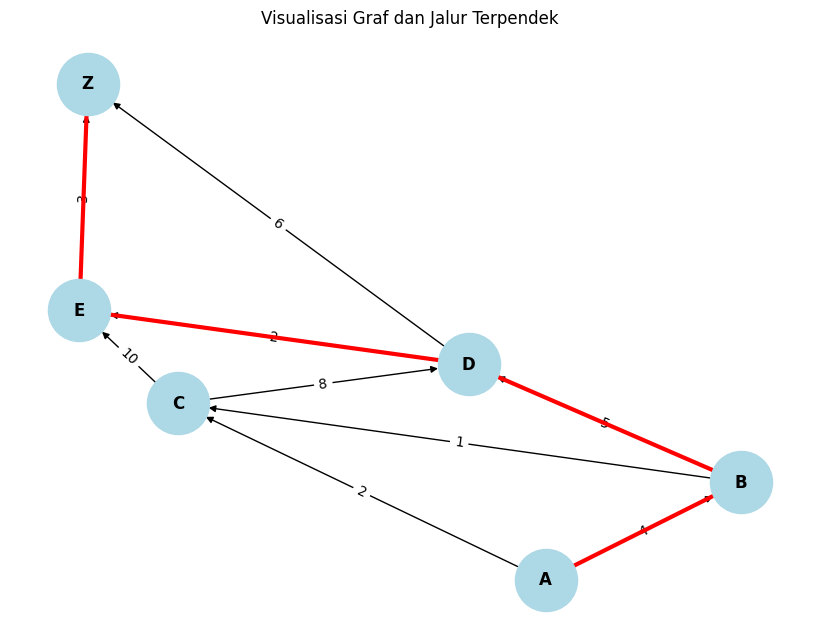

In [26]:
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
          'E': {'Z': 3},
          'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)
# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances [end_node]}")
print (f"Jalur: {''.join (shortest_path)}")
# Visualisasi
visualize_graph(graph, path=shortest_path)

### TUGAS

1. Modifikasi Graf agar Memiliki Siklus





Jarak dari A ke Z (dengan siklus): 14
Jalur (dengan siklus): ABDEZ


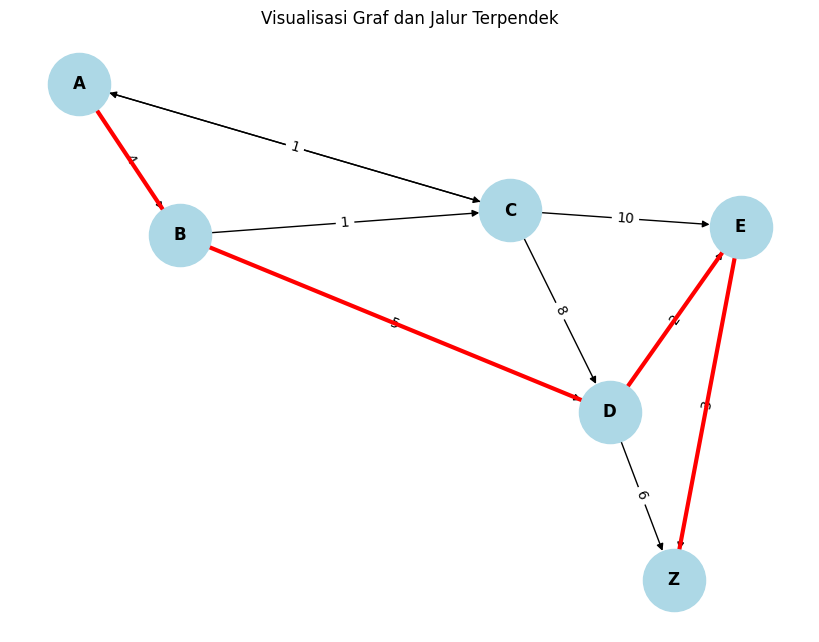

In [27]:
# Modifikasi graf untuk memiliki siklus
graph_with_cycle = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10, 'A': 1}, # Menambahkan edge C->A untuk membuat siklus
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

start_node_cycle = 'A'
end_node_cycle = 'Z'

distances_cycle, previous_cycle = dijkstra_with_paths(graph_with_cycle, start_node_cycle)
shortest_path_cycle = get_path(previous_cycle, end_node_cycle)

print(f"Jarak dari {start_node_cycle} ke {end_node_cycle} (dengan siklus): {distances_cycle[end_node_cycle]}")
print(f"Jalur (dengan siklus): {''.join(shortest_path_cycle)}")

visualize_graph(graph_with_cycle, path=shortest_path_cycle)

2. Menambahkan Simpul Baru dan Melihat Perubahan Jalur Terpendek

Jarak dari A ke Z (dengan simpul baru): 8
Jalur (dengan simpul baru): AFDEGZ


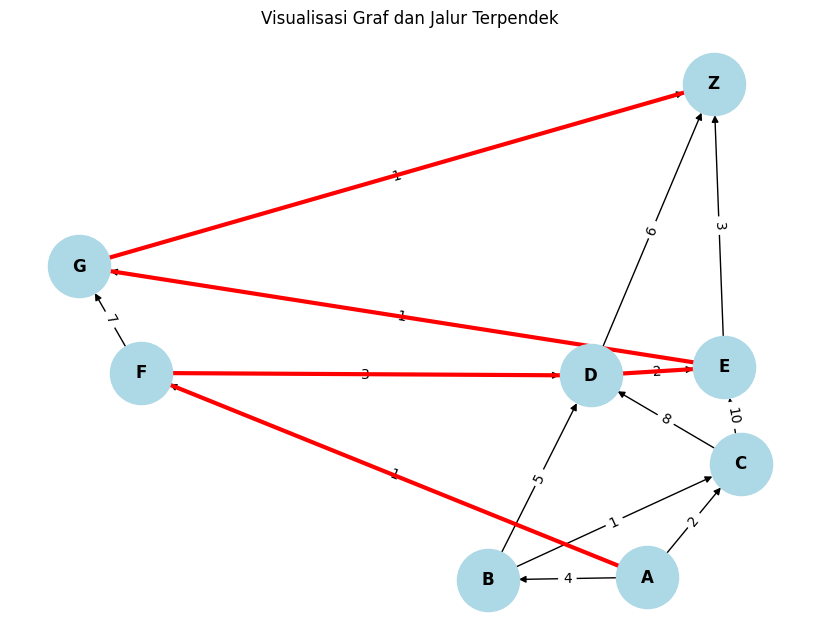

In [28]:
# Menambahkan simpul baru 'F' dan 'G' serta edge baru
graph_with_new_nodes = {
    'A': {'B': 4, 'C': 2, 'F': 1},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'G': 1},
    'F': {'D': 3, 'G': 7},
    'G': {'Z': 1},
    'Z': {}
}

start_node_new = 'A'
end_node_new = 'Z'

distances_new, previous_new = dijkstra_with_paths(graph_with_new_nodes, start_node_new)
shortest_path_new = get_path(previous_new, end_node_new)

print(f"Jarak dari {start_node_new} ke {end_node_new} (dengan simpul baru): {distances_new[end_node_new]}")
print(f"Jalur (dengan simpul baru): {''.join(shortest_path_new)}")

visualize_graph(graph_with_new_nodes, path=shortest_path_new)

3. Mengganti Tata Letak Graf

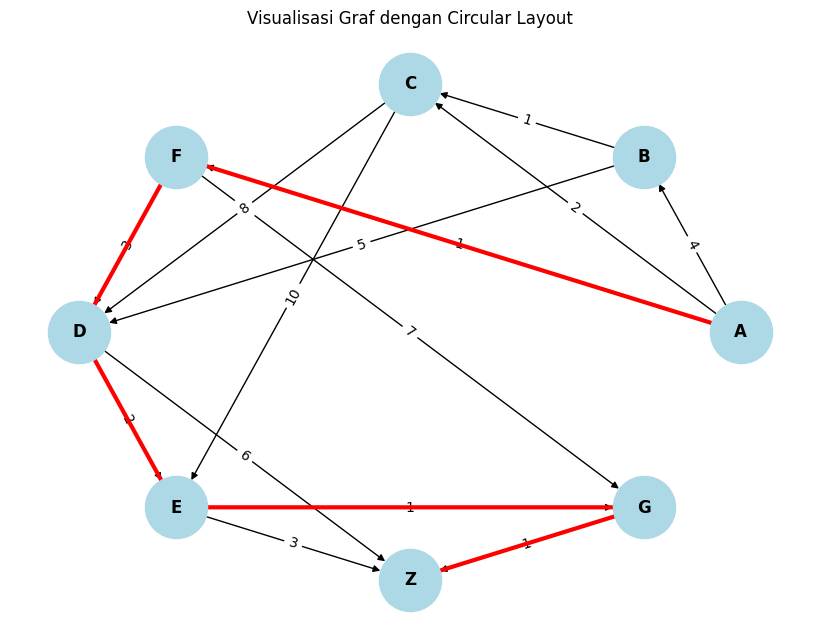

In [29]:
def visualize_graph_layout(graph, path=None, layout_function=nx.spring_layout, title="Visualisasi Graf"): # Modified to accept layout function
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = layout_function(G) # Use the provided layout function
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title(title)
    plt.axis('off')
    plt.show()

# Mengganti tata letak graf menggunakan circular_layout
visualize_graph_layout(graph_with_new_nodes, path=shortest_path_new, layout_function=nx.circular_layout, title="Visualisasi Graf dengan Circular Layout")

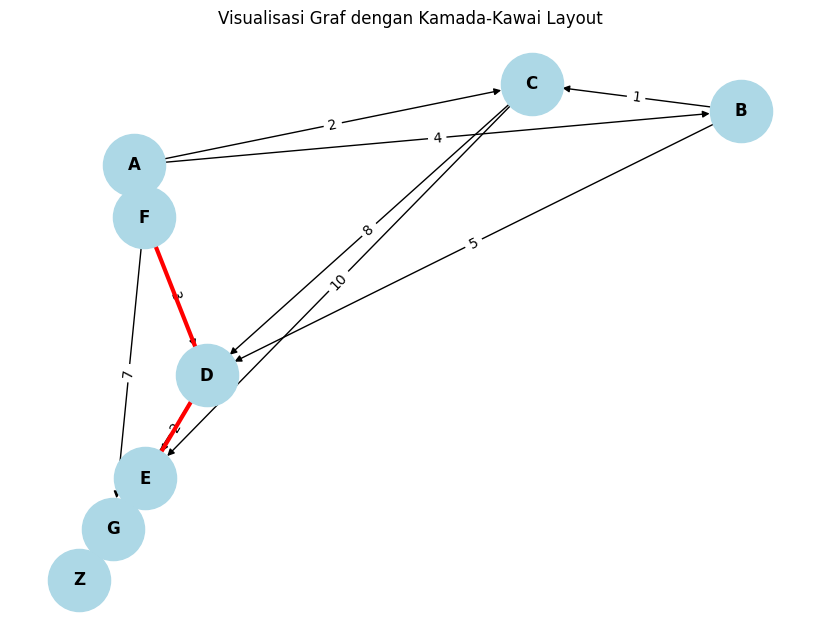

In [30]:
# Mengganti tata letak graf menggunakan kamada_kawai_layout
visualize_graph_layout(graph_with_new_nodes, path=shortest_path_new, layout_function=nx.kamada_kawai_layout, title="Visualisasi Graf dengan Kamada-Kawai Layout")